hier habe ich eine fasta Datei erstellt, die nur die Sequenzen der heavy chains beinhaltet. Ich habe mich entschlossen die doppelt vorkommenden Einträge nicht zu löschen. Außerdem wird hier auch nicht die target antigen species der jeweiligen hcain beachtet und auch die Paarung mit lchain nicht berücksichtigt.

In [32]:
from Bio import SeqIO
import pandas as pd

# Pfade
mapping_path = "../../documentation/clean_entity_mapping.csv"
fasta_path = "../../documentation/pdb_sequences.fasta"
output_path = "hchain_sequences_all.fasta"

# Mapping-Datei laden
mapping_df = pd.read_csv(mapping_path, dtype=str)
mapping_df = mapping_df[mapping_df["H_entity_id"].notna()]
mapping_df["pdb"] = mapping_df["pdb"].str.lower().str.strip()
mapping_df["H_entity_id"] = mapping_df["H_entity_id"].str.strip()

# Set aus (pdb_id, H_entity_id) erstellen
heavy_entities = set(
    (row["pdb"], row["H_entity_id"])
    for _, row in mapping_df.iterrows()
    if row["H_entity_id"].isdigit()
)

print(f"Gefundene Heavy Chain Entities im Mapping: {len(heavy_entities)}")

count_total = 0
count_written = 0

with open(output_path, "w") as out_fasta:
    for record in SeqIO.parse(fasta_path, "fasta"):
        count_total += 1

        # Header z. B. >5GGT_1|A|Homo sapiens
        header = record.id
        sequence = str(record.seq)

        # Extrahiere PDB-ID und Entity-ID
        try:
            pdb_part, _ = header.split("|", 1)
            pdb_id, entity_id = pdb_part.split("_")
            pdb_id = pdb_id.lower().strip()
            entity_id = entity_id.strip()
        except ValueError:
            continue  # falls der Header nicht dem erwarteten Format entspricht

        if (pdb_id, entity_id) in heavy_entities:
            out_fasta.write(f">{header}\n{sequence}\n")
            count_written += 1

print(f"Insgesamt {count_total} Sequenzen geprüft.")
print(f"{count_written} Heavy Chain Sequenzen basierend auf Entity-ID gespeichert.")

Gefundene Heavy Chain Entities im Mapping: 1442
Insgesamt 4317 Sequenzen geprüft.
1442 Heavy Chain Sequenzen basierend auf Entity-ID gespeichert.


In [33]:
import subprocess
import os

input_fasta = "hchain_sequences_all.fasta"
db_dir = "mmseqs_db"
result_dir = "mmseqs_result"
work_dir = "mmseqs_tmp"

os.makedirs(work_dir, exist_ok=True)

mmseqs_bin = "/opt/homebrew/bin/mmseqs"

# Datenbank erstellen
subprocess.run([
    mmseqs_bin, "createdb",
    input_fasta,
    db_dir
], check=True)

# All-vs-All-Suche
subprocess.run([
    mmseqs_bin, "search",
    db_dir, db_dir, result_dir, work_dir,
    "--threads", "4"
], check=True)

# Ergebnisse in tabellarisches Format umwandeln
subprocess.run([
    mmseqs_bin, "convertalis",
    db_dir, db_dir, result_dir,
    "result.tsv"
], check=True)

mmseqs_db exists and will be overwritten
createdb hchain_sequences_all.fasta mmseqs_db 

MMseqs Version:       	17-b804f
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to mmseqs_db_h: 0h 0m 0s 6ms
Time for merging to mmseqs_db: 0h 0m 0s 6ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 42ms
search mmseqs_db mmseqs_db mmseqs_result mmseqs_tmp --threads 4 

MMseqs Version:                        	17-b804f
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	false
Alignment mode                         	2
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0
Min alignment length                   	0
Seq. id. mode                 

CalledProcessError: Command '['/opt/homebrew/bin/mmseqs', 'search', 'mmseqs_db', 'mmseqs_db', 'mmseqs_result', 'mmseqs_tmp', '--threads', '4']' returned non-zero exit status 1.

hier habe ich alle hchain sequnces aus der fasta gegeneinander geblastet.

In [34]:
import pandas as pd
import numpy as np

# MMseqs-Ausgabe einlesen
df = pd.read_csv("result.tsv", sep="\t", header=None)
df.columns = ["query", "target", "pident", "alnlen", "mismatches", "gaps",
              "qstart", "qend", "tstart", "tend", "evalue", "bitscore"]

# Liste aller eindeutigen Sequenznamen
all_ids = sorted(set(df["query"]) | set(df["target"]))

# Leere Matrix erstellen
similarity_matrix = pd.DataFrame(
    data=np.nan,
    index=all_ids,
    columns=all_ids
)

# Matrix füllen (wir nehmen pident als Ähnlichkeitsmaß)
for _, row in df.iterrows():
    q, t, pid = row["query"], row["target"], row["pident"]
    similarity_matrix.loc[q, t] = pid
    similarity_matrix.loc[t, q] = pid  # weil All-vs-All → symmetrisch

# Diagonale mit 100 % füllen
np.fill_diagonal(similarity_matrix.values, 100)

# Optional: fehlende Werte mit 0 (oder z.B. mittlerem Wert) ersetzen
similarity_matrix = similarity_matrix.fillna(0)

# Speichern
similarity_matrix.to_csv("similarity_matrix.csv")

print("Ähnlichkeitsmatrix erfolgreich erstellt und gespeichert.")

Ähnlichkeitsmatrix erfolgreich erstellt und gespeichert.


hier ist der Code für eine Ähnlichkeitsmatrix anhand results.tsv.

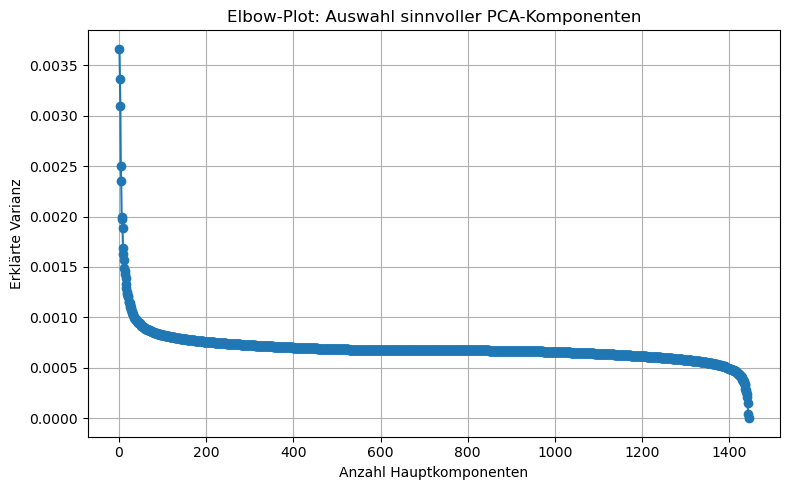

In [33]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Ähnlichkeitsmatrix laden
sim_matrix = pd.read_csv("similarity_matrix.csv", index_col=0)

# Optional: Normalisieren (falls notwendig)
# sim_matrix = sim_matrix / 100.0

# PCA mit vielen Komponenten durchführen (maximal so viele wie Features)
pca = PCA()
pca_result_full = pca.fit_transform(sim_matrix)

# Erklärte Varianz plotten (Elbow-Plot)
explained_var = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
plt.xlabel('Anzahl Hauptkomponenten')
plt.ylabel('Erklärte Varianz')
plt.title('Elbow-Plot: Auswahl sinnvoller PCA-Komponenten')
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_elbow_plot.png")
plt.show()

# Falls du dich danach z. B. für 2 PCs entscheidest:
pca_2 = PCA(n_components=4)
pca_result_2 = pca_2.fit_transform(sim_matrix)

# In DataFrame umwandeln
pca_df = pd.DataFrame(pca_result_2, columns=['PC1', 'PC2', 'PC3', 'PC4'], index=sim_matrix.index)

# Clusterlabels laden (falls vorhanden)
clusters = pd.read_csv("hchain_clusters.csv")
pca_df["cluster"] = clusters.set_index("id").loc[pca_df.index]["cluster"]



hier der Code für eine PCA anhand der Ähnlichkeitsmatrix. Außerdem hab ich die elbow Method angewendet um herauszufinden, wie viele PCs sinnvoll sind.
















Nach der PCA habe ich 2 clustering Methoden verwendet um zu schauen, welche am besten funktioniert. An ertser Stelle der Code für das hierarchische clustering und danach kmeans.

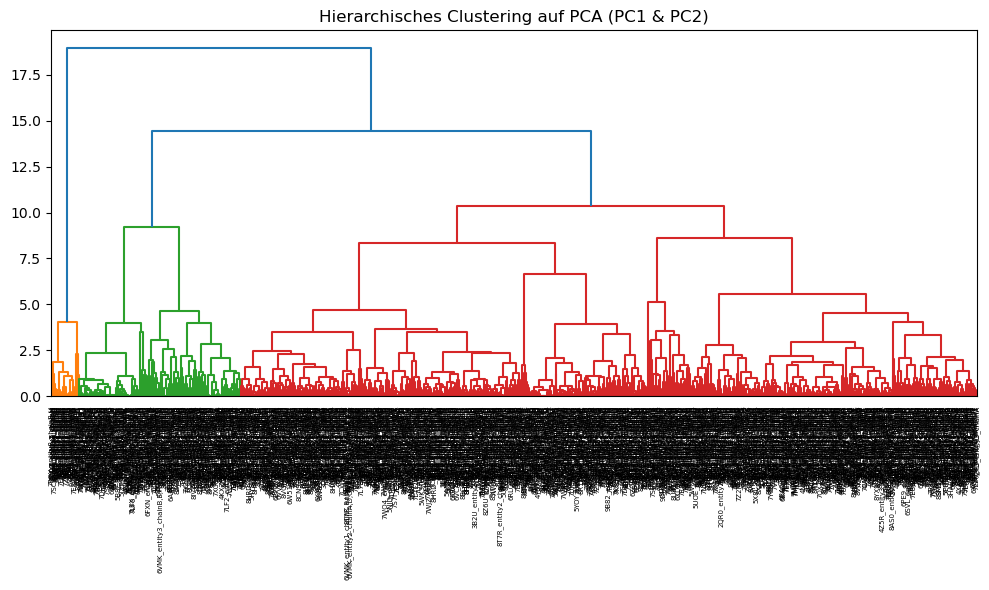

56 Cluster nach PCA-Clustering gefunden.


In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Nur PC1 und PC2 verwenden für das Clustering
pca_data = pca_df[['PC1', 'PC2']].values

# Distanzmatrix berechnen
distances = pdist(pca_data)

# Hierarchisches Clustering mit average linkage
Z = linkage(distances, method='average')

# Dendrogramm anzeigen
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=pca_df.index, leaf_rotation=90)
plt.title("Hierarchisches Clustering auf PCA (PC1 & PC2)")
plt.tight_layout()
plt.savefig("dendrogram_pca.png")
plt.show()

# Clusterlabels extrahieren (Schwellenwert ggf. anpassen)
cluster_labels_pca = fcluster(Z, t=2.0, criterion='distance')  # t=2.0 ist ein Beispiel

# Clusterlabels hinzufügen und abspeichern
pca_df["cluster_pca"] = cluster_labels_pca
pca_df.to_csv("pca_with_clusters.csv")

print(f"{len(set(cluster_labels_pca))} Cluster nach PCA-Clustering gefunden.")

hier ist das hierarchische clustering anhand der PCA. 

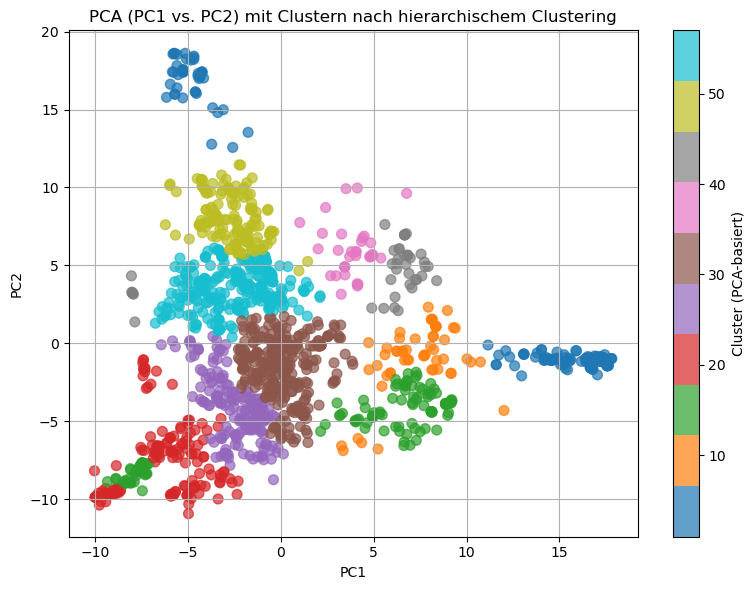

In [23]:
import matplotlib.pyplot as plt

# PCA-Plot mit neuen Clustern nach hierarchischem Clustering auf PC1 & PC2
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster_pca'],
    cmap='tab10',
    s=50,
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (PC1 vs. PC2) mit Clustern nach hierarchischem Clustering')
plt.colorbar(scatter, label='Cluster (PCA-basiert)')
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_clusters_hierarchical.png")
plt.show()

Der Code für die Visualisierung der Cluster des hierarchischen clusterings.

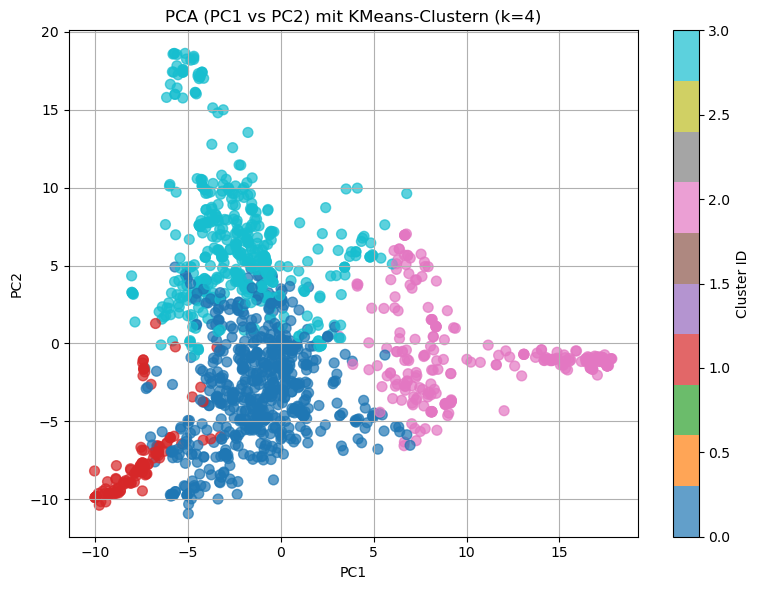

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# === Parameter ===
n_pcs = 4        # Anzahl der Hauptkomponenten
n_clusters = 4   # Anzahl gewünschter KMeans-Cluster
pc_x = 0        # X-Achse im Plot (Index beginnt bei 1 → PC2)
pc_y = 1        # Y-Achse im Plot (Index beginnt bei 1 → PC3)

# === Daten laden ===
sim_matrix = pd.read_csv("similarity_matrix.csv", index_col=0)

# === PCA durchführen ===
pca = PCA(n_components=n_pcs)
pca_result = pca.fit_transform(sim_matrix)
columns = [f"PC{i+1}" for i in range(n_pcs)]
pca_df = pd.DataFrame(pca_result, columns=columns, index=sim_matrix.index)

# === KMeans-Clustering ===
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pca_df['cluster'] = kmeans.fit_predict(pca_result)

# === Plot von PCx vs. PCy mit Clusterfarben ===
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df[f'PC{pc_x+1}'], pca_df[f'PC{pc_y+1}'],
    c=pca_df['cluster'], cmap='tab10', s=50, alpha=0.7
)
plt.xlabel(f'PC{pc_x+1}')
plt.ylabel(f'PC{pc_y+1}')
plt.title(f'PCA (PC{pc_x+1} vs PC{pc_y+1}) mit KMeans-Clustern (k={n_clusters})')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_kmeans_clusters.png")
plt.show()

# Optional: Clusterlabels speichern
pca_df[['cluster']].to_csv("pca_kmeans_clusters.csv")

Code für kmeans clustering anhand der PCA. 

k=2, Silhouette Score=0.0732
k=3, Silhouette Score=0.0648
k=4, Silhouette Score=0.0632
k=5, Silhouette Score=0.0638
k=6, Silhouette Score=0.0639
k=7, Silhouette Score=0.0641
k=8, Silhouette Score=0.0659
k=9, Silhouette Score=0.0652
k=10, Silhouette Score=0.0686
k=11, Silhouette Score=0.0678
k=12, Silhouette Score=0.0688
k=13, Silhouette Score=0.0703
k=14, Silhouette Score=0.0674
k=15, Silhouette Score=0.0693
k=16, Silhouette Score=0.0693
k=17, Silhouette Score=0.0702
k=18, Silhouette Score=0.0716
k=19, Silhouette Score=0.0719
k=20, Silhouette Score=0.0716
k=21, Silhouette Score=0.0731
k=22, Silhouette Score=0.0727
k=23, Silhouette Score=0.0714
k=24, Silhouette Score=0.0737
k=25, Silhouette Score=0.0715
k=26, Silhouette Score=0.0732
k=27, Silhouette Score=0.0744
k=28, Silhouette Score=0.0734
k=29, Silhouette Score=0.0748


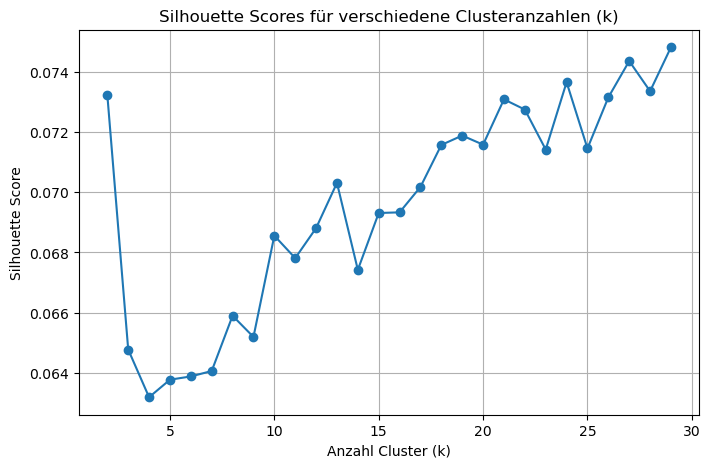

In [40]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Ähnlichkeitsmatrix laden
sim_matrix = pd.read_csv("similarity_matrix.csv", index_col=0)

# In Distanzmatrix umwandeln (1 - pident/100)
dist_matrix = 1 - (sim_matrix / 100)

# KMeans erwartet Feature-Vektoren, keine Distanzmatrix,
# deshalb müssen wir die Distanzmatrix in Vektoren umwandeln.
# Dafür können wir die MDS (Multidimensionale Skalierung) verwenden,
# oder hier als einfaches Beispiel die Distanzmatrix als Features nehmen:

# Alternativ: MDS für Dimensionalitätsreduktion (empfohlen)
from sklearn.manifold import MDS
embedding = MDS(n_components=10, dissimilarity='precomputed', random_state=42)
X = embedding.fit_transform(dist_matrix.values)

# Silhouette-Score für k von 2 bis 10 berechnen
sil_scores = []
k_range = range(2, 30)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Scores für verschiedene Clusteranzahlen (k)")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

da bin ich mir noch nicht sicher, wie ich das interpretieren soll ...